###Estudiante: Mamani Ramirez, Franco

In [56]:
import pandas as pd

# Introducción

El objetivo de este trabajo consiste en analizar distintos conjuntos de datos relacionados con ventas, clientes y campañas de marketing utilizando herramientas de análisis de datos en Python.

Durante el desarrollo del proyecto se realizaron tareas de exploración, limpieza, transformación e integración de los datos para posteriormente aplicar técnicas de estadística descriptiva, análisis exploratorio, correlación entre variables y visualización de resultados.

El propósito final es identificar patrones relevantes que contribuyan a comprender el comportamiento de las ventas y generar información útil para la toma de decisiones.

###**Etapa 1: Recopilación y Preparación de Datos**

In [57]:
def cargar_dataset(link):
  # Usamos regex para extraer el file_id del link
  file_id = link.split('/d/')[1].split('/')[0]

  # Con ese file_id generamos la url
  url = f"https://drive.google.com/uc?id={file_id}"

  # Finalmente lo importamos usando el método read_csv() con la url generada
  df = pd.read_csv(url)
  return df

#**Carga del set: Ventas**

In [58]:
# Link generado al compartir el archivo clientes.csv
link = "https://drive.google.com/file/d/1dpvV5iOAKyD7QZX8gwAZVZIefWGpnTKM/view?usp=drive_link"
df_ventas = cargar_dataset(link)
df_ventas.head(3)

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos


#**Carga del set: Marketing**

In [59]:
# Link generado al compartir el archivo clientes.csv
link = "https://drive.google.com/file/d/1NV-ICitmc8HQjhNEuUcgKqvajoBbNBT5/view?usp=drive_link"
df_marketing = cargar_dataset(link)
df_marketing.head(3)

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024


#**Carga de set: Clientes**

In [60]:
link = "hhttps://drive.google.com/file/d/1pyNXpqnOauR5tWJWj9f8C15Ygn5HmdWT/view?usp=drive_link"
df_clientes = cargar_dataset(link)
df_clientes.head(3)

,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85


##**Analisis de datos inicial de los datasets: Calidad de datos**

In [61]:
def resumen_eda(df):
    print("📊 Dimensiones del dataset")
    print(f"Filas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")
    print("-" * 40)

    print("\n🔎 Tipos de datos")
    print(df.dtypes)
    print("-" * 40)

    print("\n🔎 Primeros registros")
    print(df.head(2))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    print(df.describe(include='number'))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    try:
        print(df.describe(include='object'))
    except:
      print("No hay variables categóricas")
    print("-" * 40)

    print("\n⚠️ Valores nulos por columna")
    nulos = df.isnull().sum()
    if (nulos > 0).any():
        print(nulos[nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos en el DataFrame (0 en todas las columnas)")
    print("-" * 40)

    print("\n📌 Porcentaje de nulos por columna")
    porcentaje_nulos = df.isnull().mean() * 100
    if (porcentaje_nulos > 0).any():
        print(porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos (0% en todas las columnas)")
    print("-" * 40)

    print("\n🔁 Registros duplicados")
    duplicados = df.duplicated().sum()
    print(f"Cantidad de duplicados: {duplicados}")
    print("-" * 40)

In [62]:
dataframes = {
    'VENTAS': df_ventas,
    'MARKETING': df_marketing,
    'CLIENTES': df_clientes
}

for nombre, df in dataframes.items():
    print("\n" * 2)
    print("=" * 60)
    print(f"ANÁLISIS INICIAL - {nombre}")
    print("=" * 60)
    resumen_eda(df)




ANÁLISIS INICIAL - VENTAS
📊 Dimensiones del dataset
Filas: 3035
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
dtype: object
----------------------------------------

🔎 Primeros registros
   id_venta           producto   precio  cantidad fecha_venta   categoria
0       792  Cuadro decorativo   $69.94       5.0  02/01/2024  Decoración
1       811    Lámpara de mesa  $105.10       5.0  02/01/2024  Decoración
----------------------------------------

📈 Estadísticas descriptivas
          id_venta     cantidad
count  3035.000000  3033.000000
mean   1499.851400     6.496538
std     866.465379     3.457250
min       1.000000     1.000000
25%     748.500000     3.000000
50%    1502.000000     7.000000
75%    2249.500000     9.000000
max    3000.000000    12.000000
----------------------------------------

📈 Estadísticas descriptiv

##Informe de la calidad de datos:

##Resumen General
Tras analizar los tres conjuntos de datos, se observa que el dataset de VENTAS presenta los mayores problemas de calidad, mientras que MARKETING y CLIENTES muestran una calidad de datos óptima.

**1. Dataset VENTAS (3,035 registros)**


**Problemas identificados:**

Valores nulos: 2 valores nulos en la columna precio y 2 en cantidad (0.066% del total cada una). Aunque el porcentaje es bajo, requiere tratamiento.

Registros duplicados: 35 filas completamente duplicadas (1.15% del dataset), lo que puede distorsionar análisis de ventas y métricas agregadas.

Problemas de tipo de dato: La columna precio está almacenada como texto/object (con formato $69.94), cuando debería ser numérica para cálculos.

Recomendaciones: Limpiar duplicados, convertir precio a numérico y decidir si eliminar o imputar los 2 valores nulos.

**2. Dataset MARKETING (90 registros)**
Estado: ✅ Excelente calidad

Valores nulos: 0 en todas las columnas

Registros duplicados: 0

Tipos de datos consistentes

Recomendaciones: Ninguna acción correctiva necesaria.

**3. Dataset CLIENTES (567 registros)**
Estado: ✅ Excelente calidad

Valores nulos: 0 en todas las columnas

Registros duplicados: 0

Tipos de datos correctos

Recomendaciones: Ninguna acción correctiva necesaria.

#Conclusión

Prioridad de acción: Enfocar los esfuerzos de limpieza en el dataset VENTAS, específicamente en la eliminación de duplicados, conversión del campo precio y tratamiento de los valores nulos.


###**Etapa 2: Preprocesamiento y Limpieza de Datos**

**1- Limpieza de Datos**

In [63]:
#Cambio del nombre de columna de df_marketing: id_campanha por id_campana

df_marketing.rename(columns={'id_campanha': 'id_campana'}, inplace=True)




**1. DATASET VENTAS**

In [64]:
# 1. Eliminar registros duplicados
df_ventas = df_ventas.drop_duplicates()

# 2. Eliminar filas con valores nulos (son solo 2 filas)
df_ventas = df_ventas.dropna()

# 3. Convertir columna 'precio' de texto a número
df_ventas['precio'] = df_ventas['precio'].str.lstrip('$').astype(float)

# 4. Convertir 'fecha_venta' a tipo datetime
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'], format='%d/%m/%Y')

# 5. Verificar que 'cantidad' sea entero
df_ventas['cantidad'] = df_ventas['cantidad'].astype(int)

# 6. Verificar resultado final
print(f"Filas después de limpieza: {len(df_ventas)}")
print(df_ventas.dtypes)

Filas después de limpieza: 2998
id_venta                int64
producto               object
precio                float64
cantidad                int64
fecha_venta    datetime64[ns]
categoria              object
dtype: object


**2. DATASET MARKETING**

In [65]:
# 1. Renombrar columna
df_marketing.rename(columns={'id_campanha': 'id_campana'}, inplace=True)

# 2. Convertir fechas a tipo datetime
df_marketing['fecha_inicio'] = pd.to_datetime(df_marketing['fecha_inicio'], format='%d/%m/%Y')
df_marketing['fecha_fin'] = pd.to_datetime(df_marketing['fecha_fin'], format='%d/%m/%Y')

# 3. Calcular duración de campaña
df_marketing['duracion_dias'] = (df_marketing['fecha_fin'] - df_marketing['fecha_inicio']).dt.days

# 4. Verificar
print(df_marketing.dtypes)
print(df_marketing.head(2))

id_campana                int64
producto                 object
canal                    object
costo                   float64
fecha_inicio     datetime64[ns]
fecha_fin        datetime64[ns]
duracion_dias             int64
dtype: object
   id_campana         producto canal  costo fecha_inicio  fecha_fin  \
0          74  Adorno de pared    TV   4.81   2024-03-20 2024-05-03   
1          12           Tablet  RRSS   3.40   2024-03-26 2024-05-13   

   duracion_dias  
0             44  
1             48  


**3. DATASET CLIENTES**

In [66]:
# 1. Verificar rangos de edad (sin cambios obligatorios)
print(f"Edad mínima: {df_clientes['edad'].min()}")
print(f"Edad máxima: {df_clientes['edad'].max()}")

# 2. Crear columna de segmento por ingresos
df_clientes['segmento_ingresos'] = pd.cut(
    df_clientes['ingresos'],
    bins=[0, 30000, 50000, 90000],
    labels=['Bajo', 'Medio', 'Alto']
)

# 3. Normalizar nombres de ciudades (primera letra mayúscula)
df_clientes['ciudad'] = df_clientes['ciudad'].str.title()

# 4. Verificar integridad
print(f"Clientes únicos: {df_clientes['id_cliente'].nunique()}")
print(f"Nombres únicos: {df_clientes['nombre'].nunique()}")  # Debería ser 567

Edad mínima: 20
Edad máxima: 81
Clientes únicos: 567
Nombres únicos: 567


##**Informe de Verificación y Resultados de Limpieza de Datos**

**Dataset VENTAS - Estado final: Óptimo**

El dataset de ventas experimentó las siguientes transformaciones: se redujo de 3,035 a 2,998 filas después de eliminar 35 registros duplicados y 2 filas con valores nulos en las columnas precio y cantidad. La columna precio se convirtió de texto con formato "$69.94" a tipo numérico float64 con valor 69.94. La columna cantidad pasó de float64 a int64. La columna fecha_venta se convirtió de object a datetime64[ns].

Se generó una advertencia menor de sintaxis por el uso de "$" en la expresión regular, aunque la función funcionó correctamente. Para evitarlo en el futuro, se recomienda usar r'[$,]' (raw string).

**Dataset MARKETING - Estado final: Óptimo**

El dataset de marketing experimentó las siguientes transformaciones: se renombró la columna id_campanha a id_campaña. Las columnas fecha_inicio y fecha_fin se convirtieron de object a datetime64[ns]. Se añadió una nueva columna llamada duracion_dias que calcula automáticamente los días de duración de cada campaña.

Como validación de muestra, la campaña 1 del 20/03/2024 al 03/05/2024 resultó en 44 días, y la campaña 2 del 26/03/2024 al 13/05/2024 resultó en 48 días, ambos cálculos correctos.

Se observa que el cambio de nombre generó id_campana sin tilde, cuando originalmente se solicitó id_campaña con tilde. Se sugiere verificar si la tilde es necesaria o se prefiere sin acento.

**Dataset CLIENTES - Estado final: Óptimo**

El dataset de clientes no requirió modificaciones estructurales ya que se encontraba limpio. Se realizaron verificaciones de integridad que confirmaron su calidad: total de 567 clientes, edad mínima de 20 años, edad máxima de 81 años (rangos razonables), 567 clientes únicos sin duplicados, y 567 nombres únicos.

##**Transformación de Datos**

**Transformaciones para df_ventas**

In [67]:
# 1. Calcular ingreso total por transacción
df_ventas['ingreso_total'] = df_ventas['precio'] * df_ventas['cantidad']

# 2. Extraer componentes de fecha para análisis temporal
df_ventas['año'] = df_ventas['fecha_venta'].dt.year
df_ventas['mes'] = df_ventas['fecha_venta'].dt.month
df_ventas['dia'] = df_ventas['fecha_venta'].dt.day
df_ventas['dia_semana'] = df_ventas['fecha_venta'].dt.dayofweek  # 0=lunes, 6=domingo
df_ventas['nombre_mes'] = df_ventas['fecha_venta'].dt.month_name()

# 3. Crear columna de trimestre
df_ventas['trimestre'] = df_ventas['fecha_venta'].dt.quarter

# 4. Identificar si es fin de semana
df_ventas['es_fin_semana'] = df_ventas['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

# 5. Calcular precio promedio por categoría
precio_promedio_categoria = df_ventas.groupby('categoria')['precio'].transform('mean')
df_ventas['precio_sobre_promedio_categoria'] = df_ventas['precio'] > precio_promedio_categoria

#Transformación 1: Calcular ingreso total por transacción

Esta transformación crea una nueva columna llamada ingreso_total. Multiplica el precio del producto por la cantidad vendida en cada transacción. Esto es necesario porque el dataset original solo tiene precio y cantidad por separado, pero no el monto total de cada venta. Sin esta columna no se puede calcular cuánto dinero generó cada operación.

#Transformación 2: Extraer componentes de fecha para análisis temporal

Esta transformación toma la columna fecha_venta y extrae diferentes partes de la fecha en columnas separadas. La columna año guarda el año de la venta, mes guarda el número del mes (1 al 12), dia guarda el día del mes, dia_semana guarda un número del 0 al 6 donde 0 es lunes y 6 es domingo, y nombre_mes guarda el nombre del mes como texto. Esto se hace porque trabajar con la fecha completa es complicado para hacer agrupaciones. Tener año y mes por separado permite sumar ventas por mes o por año fácilmente.

#Transformación 3: Crear columna de trimestre

Esta transformación crea la columna trimestre, que asigna un número del 1 al 4 según en qué trimestre del año ocurrió cada venta. El primer trimestre son enero, febrero y marzo, el segundo trimestre abril, mayo y junio, y así sucesivamente. Esto se hace porque muchos análisis comerciales evalúan el rendimiento por trimestres, permitiendo comparar períodos de tres meses.

#Transformación 4: Identificar si es fin de semana

Esta transformación crea la columna es_fin_semana. Usa el día de la semana que ya se extrajo antes y pregunta si ese número es 5, 6 o mayor. Los días 5 y 6 corresponden a sábado y domingo. Si es fin de semana asigna el valor 1, y si es día de semana asigna 0. Esto se hace para poder comparar el comportamiento de compra entre fines de semana y días hábiles, lo cual es útil para planificar promociones.

#Transformación 5: Comparar precio con el promedio de su categoría

Esta transformación primero calcula el precio promedio de cada categoría de producto usando groupby y transform. Luego crea una columna llamada precio_sobre_promedio_categoria que tiene el valor Verdadero si el precio del producto es mayor al promedio de su categoría, o Falso si es menor o igual. Esto se hace para identificar dentro de cada categoría qué productos son más caros que el promedio, lo cual ayuda a entender si los productos caros se comportan diferente a los baratos.

##**Transformaciones para df_marketing**

In [68]:
# 1. Calcular duración de cada campaña en días
df_marketing['duracion_dias'] = (df_marketing['fecha_fin'] - df_marketing['fecha_inicio']).dt.days

# 2. Extraer mes y año de inicio
df_marketing['año_inicio'] = df_marketing['fecha_inicio'].dt.year
df_marketing['mes_inicio'] = df_marketing['fecha_inicio'].dt.month

# 3. Calcular costo por día de campaña
df_marketing['costo_por_dia'] = df_marketing['costo'] / df_marketing['duracion_dias']

# 4. Clasificar campañas por duración
def clasificar_duracion(dias):
    if dias <= 30:
        return 'Corta'
    elif dias <= 60:
        return 'Media'
    else:
        return 'Larga'

df_marketing['tipo_duracion'] = df_marketing['duracion_dias'].apply(clasificar_duracion)

# 5. Clasificar campañas por costo
def clasificar_costo(costo):
    if costo <= 4:
        return 'Bajo'
    elif costo <= 6:
        return 'Medio'
    else:
        return 'Alto'

df_marketing['tipo_costo'] = df_marketing['costo'].apply(clasificar_costo)

**Transformación 1: Calcular duración de cada campaña en días**

Esta transformación crea una columna llamada duracion_dias. Resta la fecha de inicio de la fecha de fin para obtener la cantidad total de días que duró cada campaña. Esto es necesario porque el dataset original solo tiene las fechas de inicio y fin, pero no la duración calculada. Saber los días de duración permite evaluar si las campañas más largas son más efectivas que las cortas.

**Transformación 2: Extraer mes y año de inicio**

Esta transformación toma la columna fecha_inicio y extrae el año y el mes en columnas separadas. La columna año_inicio guarda el año en que comenzó la campaña y la columna mes_inicio guarda el número del mes del 1 al 12. Esto se hace para poder agrupar campañas por mes o por año, lo cual facilita comparar la inversión en marketing en diferentes períodos de tiempo.

**Transformación 3: Calcular costo por día de campaña**

Esta transformación crea una columna llamada costo_por_dia. Divide el costo total de la campaña por la duración en días que ya se calculó antes. El resultado es cuánto dinero se gastó por cada día que duró la campaña. Esto se hace para poder comparar la eficiencia entre campañas de diferente duración. Una campaña cara pero muy larga puede tener un costo por día bajo, lo cual es un dato relevante para evaluar su rendimiento.

**Transformación 4: Clasificar campañas por duración**

Esta transformación primero define una función llamada clasificar_duracion. Esta función recibe la cantidad de días y devuelve la etiqueta Corta si los días son menores o iguales a 30, Media si los días están entre 31 y 60, o Larga si los días son mayores a 60. Luego aplica esta función a la columna duracion_dias para crear una nueva columna llamada tipo_duracion. Esto se hace porque agrupar las campañas por categorías de duración facilita el análisis comparativo. Es más sencillo responder preguntas como "¿las campañas largas generan más ventas?" usando etiquetas como Corta, Media y Larga en lugar de usar números exactos.

**Transformación 5: Clasificar campañas por costo**

Esta transformación define una función llamada clasificar_costo. Esta función recibe el costo de la campaña y devuelve la etiqueta Bajo si el costo es menor o igual a 4, Medio si el costo está entre 4 y 6, o Alto si el costo es mayor a 6. Luego aplica esta función a la columna costo para crear una nueva columna llamada tipo_costo. Esto se hace para segmentar las campañas por nivel de inversión. Permite analizar si las campañas más caras realmente generan mejores resultados que las campañas de costo bajo o medio, lo cual será útil al momento de calcular el retorno de inversión.

#**Transformaciones para df_clientes**

In [69]:
# 1. Crear rangos de edad
def rango_edad(edad):
    if edad < 30:
        return 'Joven (18-29)'
    elif edad < 50:
        return 'Adulto (30-49)'
    else:
        return 'Mayor (50+)'

df_clientes['grupo_etario'] = df_clientes['edad'].apply(rango_edad)

# 2. Crear rangos de ingresos
def rango_ingresos(ingreso):
    if ingreso < 30000:
        return 'Bajo'
    elif ingreso < 50000:
        return 'Medio'
    else:
        return 'Alto'

df_clientes['segmento_ingresos'] = df_clientes['ingresos'].apply(rango_ingresos)

# 3. Normalizar nombres de ciudades (primer letra mayúscula)
df_clientes['ciudad'] = df_clientes['ciudad'].str.title()

**Transformación 1: Crear rangos de edad**

Esta transformación primero define una función llamada rango_edad. Esta función recibe la edad de un cliente y evalúa en qué rango se encuentra. Si la edad es menor a 30 años, devuelve la etiqueta Joven (18-29). Si la edad es menor a 50 años pero mayor o igual a 30, devuelve la etiqueta Adulto (30-49). Si la edad es mayor o igual a 50, devuelve la etiqueta Mayor (50+). Luego aplica esta función a la columna edad del dataframe usando apply, y crea una nueva columna llamada grupo_etario con los resultados. Esto se hace porque la edad exacta es un dato muy específico que dificulta hacer análisis grupales. Al agrupar las edades en tres categorías se puede segmentar a los clientes por generaciones y analizar si diferentes grupos etarios compran productos distintos.

**Transformación 2: Crear rangos de ingresos**

Esta transformación define una función llamada rango_ingresos. Esta función recibe el ingreso de un cliente y evalúa en qué rango se encuentra. Si el ingreso es menor a 30000, devuelve la etiqueta Bajo. Si el ingreso es menor a 50000 pero mayor o igual a 30000, devuelve la etiqueta Medio. Si el ingreso es mayor o igual a 50000, devuelve la etiqueta Alto. Luego aplica esta función a la columna ingresos del dataframe usando apply, y crea una nueva columna llamada segmento_ingresos con los resultados. Esto se hace para segmentar a los clientes por su poder adquisitivo. El ingreso exacto es útil pero agruparlo en categorías permite responder preguntas como "¿los clientes de altos ingresos compran productos más caros?" de manera más sencilla que usando números exactos.

**Transformación 3: Normalizar nombres de ciudades**

Esta transformación toma la columna ciudad del dataframe y aplica el método title() de pandas. Este método convierte la primera letra de cada palabra en mayúscula y el resto de las letras en minúscula. Por ejemplo, "mar del plata" se convierte en "Mar Del Plata" y "MAR DEL PLATA" también se convierte en "Mar Del Plata". Esto se hace porque los nombres de ciudades pueden estar escritos de diferentes maneras en el dataset original. Si no se normalizan, al momento de agrupar o filtrar por ciudad, valores como "mar del plata", "Mar del Plata" y "MAR DEL PLATA" serían tratados como tres ciudades diferentes cuando en realidad son la misma. La normalización evita este problema.

#**Verificación final de transformaciones**

In [70]:

print("=== VENTAS ===")
print(f"Total de filas: {len(df_ventas)}")
print(f"Total de columnas: {len(df_ventas.columns)}")
print(f"Nuevas columnas añadidas: {df_ventas.columns.tolist()}")

print("\n=== MARKETING ===")
print(f"Total de filas: {len(df_marketing)}")
print(f"Nuevas columnas añadidas: {df_marketing.columns.tolist()}")

print("\n=== CLIENTES ===")
print(f"Total de filas: {len(df_clientes)}")
print(f"Nuevas columnas añadidas: {df_clientes.columns.tolist()}")

=== VENTAS ===
Total de filas: 2998
Total de columnas: 15
Nuevas columnas añadidas: ['id_venta', 'producto', 'precio', 'cantidad', 'fecha_venta', 'categoria', 'ingreso_total', 'año', 'mes', 'dia', 'dia_semana', 'nombre_mes', 'trimestre', 'es_fin_semana', 'precio_sobre_promedio_categoria']

=== MARKETING ===
Total de filas: 90
Nuevas columnas añadidas: ['id_campana', 'producto', 'canal', 'costo', 'fecha_inicio', 'fecha_fin', 'duracion_dias', 'año_inicio', 'mes_inicio', 'costo_por_dia', 'tipo_duracion', 'tipo_costo']

=== CLIENTES ===
Total de filas: 567
Nuevas columnas añadidas: ['id_cliente', 'nombre', 'edad', 'ciudad', 'ingresos', 'segmento_ingresos', 'grupo_etario']


**Verificación de transformaciones aplicadas**

Para el dataset de ventas, el proceso de transformación se aplicó correctamente sobre las 2998 filas que resultaron de la limpieza previa. El dataset original tenía 6 columnas y luego de las transformaciones pasó a tener 15 columnas. Las nuevas columnas añadidas son ingreso_total, año, mes, dia, dia_semana, nombre_mes, trimestre, es_fin_semana y precio_sobre_promedio_categoria. Todas las transformaciones se ejecutaron sin errores.

Para el dataset de marketing, el proceso de transformación se aplicó correctamente sobre las 90 filas originales. Las nuevas columnas añadidas son duracion_dias, año_inicio, mes_inicio, costo_por_dia, tipo_duracion y tipo_costo. Además se mantuvo el cambio de nombre de la columna id_campanha a id_campana. Todas las transformaciones se ejecutaron sin errores.

Para el dataset de clientes, el proceso de transformación se aplicó correctamente sobre las 567 filas originales. Las nuevas columnas añadidas son segmento_ingresos y grupo_etario. La columna ciudad fue normalizada pero no se cuenta como nueva porque reemplazó a la columna original. Todas las transformaciones se ejecutaron sin errores.

## 3 - Agregación

Resumen de ventas por categoría de producto

In [71]:
# Resumen de ventas por categoría de producto
resumen_categoria = df_ventas.groupby('categoria').agg({
    'ingreso_total': 'sum',
    'cantidad': 'sum',
    'id_venta': 'count',
    'precio': 'mean'
}).round(2)

# Renombrar columnas para mayor claridad
resumen_categoria.columns = ['ingreso_total', 'unidades_vendidas', 'cantidad_transacciones', 'precio_promedio']

# Ordenar por ingreso total de mayor a menor
resumen_categoria = resumen_categoria.sort_values('ingreso_total', ascending=False)

# Mostrar el resumen
print("=== RESUMEN DE VENTAS POR CATEGORÍA ===")
print(resumen_categoria)

=== RESUMEN DE VENTAS POR CATEGORÍA ===
                   ingreso_total  unidades_vendidas  cantidad_transacciones  \
categoria                                                                     
Electrodomésticos      505299.63               6592                    1000   
Electrónica            482577.80               6413                     998   
Decoración             479216.09               6490                    1000   

                   precio_promedio  
categoria                           
Electrodomésticos            76.52  
Electrónica                  75.25  
Decoración                   74.10  


Análisis de ingresos generados por categoría

In [72]:
# Análisis de ingresos generados por categoría
ingresos_categoria = df_ventas.groupby('categoria')['ingreso_total'].agg(['sum', 'mean', 'min', 'max', 'count']).round(2)

# Renombrar columnas
ingresos_categoria.columns = ['ingreso_total', 'ingreso_promedio_por_venta', 'ingreso_minimo', 'ingreso_maximo', 'cantidad_ventas']

# Calcular participación porcentual de cada categoría en el ingreso total
ingresos_categoria['participacion_porcentual'] = (ingresos_categoria['ingreso_total'] / ingresos_categoria['ingreso_total'].sum()) * 100
ingresos_categoria['participacion_porcentual'] = ingresos_categoria['participacion_porcentual'].round(2)

# Calcular ingreso acumulado
ingresos_categoria = ingresos_categoria.sort_values('ingreso_total', ascending=False)
ingresos_categoria['ingreso_acumulado'] = ingresos_categoria['ingreso_total'].cumsum()
ingresos_categoria['ingreso_acumulado_porcentaje'] = (ingresos_categoria['ingreso_acumulado'] / ingresos_categoria['ingreso_total'].sum()) * 100
ingresos_categoria['ingreso_acumulado_porcentaje'] = ingresos_categoria['ingreso_acumulado_porcentaje'].round(2)

# Mostrar el análisis
print("=== ANÁLISIS DE INGRESOS POR CATEGORÍA ===")
print(ingresos_categoria)

# Identificar categoría principal
categoria_top = ingresos_categoria.index[0]
print(f"\n📌 La categoría que más ingresos genera es: {categoria_top}")
print(f"📌 Genera ${ingresos_categoria.loc[categoria_top, 'ingreso_total']:,.2f} que representa el {ingresos_categoria.loc[categoria_top, 'participacion_porcentual']}% del total")

# Identificar si hay concentración
if ingresos_categoria.loc[ingresos_categoria.index[0], 'participacion_porcentual'] > 50:
    print("📌 Hay alta concentración de ingresos en una sola categoría")
else:
    print("📌 Los ingresos están distribuidos entre varias categorías")

=== ANÁLISIS DE INGRESOS POR CATEGORÍA ===
                   ingreso_total  ingreso_promedio_por_venta  ingreso_minimo  \
categoria                                                                      
Electrodomésticos      505299.63                      505.30           26.30   
Electrónica            482577.80                      483.54           27.83   
Decoración             479216.09                      479.22           29.17   

                   ingreso_maximo  cantidad_ventas  participacion_porcentual  \
categoria                                                                      
Electrodomésticos         1485.96             1000                     34.44   
Electrónica               1488.12              998                     32.89   
Decoración                1449.48             1000                     32.66   

                   ingreso_acumulado  ingreso_acumulado_porcentaje  
categoria                                                           
Electrodomésticos

**Conclusiones del análisis de ventas por categoría de producto**

Los resultados muestran que las tres categorías de productos tienen un rendimiento muy equilibrado, sin que ninguna domine claramente sobre las demás.

La categoría Electrodomésticos es la que más ingresos genera con un total de 505,299.63 pesos, lo que representa el 34.44 por ciento del ingreso total. Esta categoría realizó 1000 transacciones y vendió 6592 unidades, con un precio promedio de 76.52 pesos por producto.

La categoría Electrónica ocupa el segundo lugar con ingresos de 482,577.80 pesos, que representan el 32.89 por ciento del total. Realizó 998 transacciones y vendió 6413 unidades, con un precio promedio de 75.25 pesos. Sus ingresos son solo un 4.7 por ciento menores que los de Electrodomésticos.

La categoría Decoración se ubica en tercer lugar con ingresos de 479,216.09 pesos, que representan el 32.66 por ciento del total. Realizó 1000 transacciones y vendió 6490 unidades, con un precio promedio de 74.10 pesos. La diferencia con la primera categoría es de apenas el 5.4 por ciento.

En cuanto al ingreso promedio por venta, las tres categorías muestran valores muy similares: Electrodomésticos promedia 505.30 pesos por transacción, Electrónica 483.54 pesos y Decoración 479.22 pesos.

El análisis de concentración indica que ninguna categoría supera el 50 por ciento de participación. Electrodomésticos tiene el 34.44 por ciento, Electrónica el 32.89 por ciento y Decoración el 32.66 por ciento. Esto confirma que los ingresos están distribuidos de manera bastante equitativa entre las tres categorías.

El ingreso acumulado muestra que las dos primeras categorías juntas, Electrodomésticos y Electrónica, acumulan el 67.34 por ciento del ingreso total. Las tres categorías suman un ingreso total de 1,467,093.52 pesos.

Como conclusión principal, no hay una categoría claramente dominante. Las tres categorías tienen un desempeño muy parecido en términos de ingresos, volumen de ventas y precio promedio. Esto sugiere que el negocio no depende de una sola categoría y que todas son igualmente importantes para los ingresos totales.



## Integración de Datos

 Para poder comparar si una venta ocurrió durante una campaña, necesitamos que todas las fechas estén en el mismo formato. Convertimos las fechas a solo fecha sin hora para facilitar la comparación.

In [73]:
# Convertir fecha_venta a solo fecha (sin hora)
df_ventas['fecha_solo'] = df_ventas['fecha_venta'].dt.date

# Convertir fechas de marketing a solo fecha
df_marketing['fecha_inicio_solo'] = df_marketing['fecha_inicio'].dt.date
df_marketing['fecha_fin_solo'] = df_marketing['fecha_fin'].dt.date

 **Verificar rangos de fechas de las campañas**

Antes de asignar campañas a las ventas, conviene saber si los rangos de fechas se superponen. Si las ventas son de fechas muy anteriores o posteriores a las campañas, muchas quedarán sin asignar.



In [74]:
# Ver el período que cubren las campañas
print("Fechas de inicio de campañas:")
print(df_marketing[['id_campana', 'fecha_inicio_solo', 'fecha_fin_solo']].head(3))
print(f"\nFecha más temprana de campaña: {df_marketing['fecha_inicio_solo'].min()}")
print(f"Fecha más tardía de campaña: {df_marketing['fecha_fin_solo'].max()}")
print(f"\nRango de fechas de ventas: {df_ventas['fecha_solo'].min()} a {df_ventas['fecha_solo'].max()}")

Fechas de inicio de campañas:
   id_campana fecha_inicio_solo fecha_fin_solo
0          74        2024-03-20     2024-05-03
1          12        2024-03-26     2024-05-13
2          32        2024-03-28     2024-04-20

Fecha más temprana de campaña: 2024-03-20
Fecha más tardía de campaña: 2025-02-14

Rango de fechas de ventas: 2024-01-02 a 2024-12-30


**Crear función para asignar campaña a cada venta**

Esta función recibe una fecha de venta, recorre todas las campañas y verifica si la fecha está entre el inicio y el fin de alguna campaña. Si encuentra una, devuelve el id de esa campaña. Si recorre todas y no encuentra ninguna, devuelve "Sin campaña".

In [75]:
# Definir función que busca qué campaña estaba activa en una fecha
def asignar_campana(fecha_venta):
    for i, campana in df_marketing.iterrows():
        if campana['fecha_inicio_solo'] <= fecha_venta <= campana['fecha_fin_solo']:
            return campana['id_campana']
    return 'Sin campaña'

**Asignar campaña a todas las ventas**

Aplicamos la función creada en el paso anterior a cada fila del dataframe de ventas. Esto crea una nueva columna que indica qué campaña estaba activa en el momento de cada venta. Luego contamos cuántas ventas tiene cada campaña y el porcentaje que logramos asignar.

In [76]:
# Aplicar la función a cada venta
df_ventas['campana_asignada'] = df_ventas['fecha_solo'].apply(asignar_campana)

# Ver resultados de la asignación
print(df_ventas['campana_asignada'].value_counts())
print(f"\nPorcentaje de ventas con campaña: {df_ventas[df_ventas['campana_asignada'] != 'Sin campaña'].shape[0] / len(df_ventas) * 100:.1f}%")

campana_asignada
Sin campaña    686
74             402
72             180
55             176
36             139
34             131
35             122
14             113
79             100
40              96
86              94
12              85
18              82
45              72
57              63
24              62
6               61
43              58
47              56
67              53
90              39
5               36
75              36
21              25
4               25
9                6
Name: count, dtype: int64

Porcentaje de ventas con campaña: 77.1%


**Integrar datos de marketing a las ventas**

Hacemos un merge o combinación entre ventas y marketing. Usamos left join para que todas las ventas se mantengan, incluso aquellas sin campaña. Traemos columnas útiles de marketing como el canal usado, el costo de la campaña, la duración y las clasificaciones que creamos antes.

In [77]:
# Traer información de las campañas a cada venta
ventas_integradas = df_ventas.merge(
    df_marketing[['id_campana', 'canal', 'costo', 'duracion_dias', 'tipo_duracion', 'tipo_costo']],
    left_on='campana_asignada',
    right_on='id_campana',
    how='left'
)

# Eliminar la columna duplicada
ventas_integradas = ventas_integradas.drop('id_campana', axis=1)

print(f"Filas después de integración: {len(ventas_integradas)}")
print(f"Columnas del dataset integrado: {ventas_integradas.columns.tolist()}")

Filas después de integración: 2998
Columnas del dataset integrado: ['id_venta', 'producto', 'precio', 'cantidad', 'fecha_venta', 'categoria', 'ingreso_total', 'año', 'mes', 'dia', 'dia_semana', 'nombre_mes', 'trimestre', 'es_fin_semana', 'precio_sobre_promedio_categoria', 'fecha_solo', 'campana_asignada', 'canal', 'costo', 'duracion_dias', 'tipo_duracion', 'tipo_costo']


**Calcular ROI de cada campaña**

Agrupamos las ventas por campaña para saber cuánto ingresó cada una. Sumamos el ingreso_total, contamos las ventas y traemos el costo de cada campaña. Luego calculamos el ROI restando el costo al ingreso, dividiendo por el costo y multiplicando por 100. Esto muestra qué campañas fueron más rentables.

In [78]:
# Agrupar por campaña y calcular ingresos y ventas
roi_campanas = ventas_integradas.groupby('campana_asignada').agg({
    'ingreso_total': 'sum',
    'id_venta': 'count',
    'costo': 'first'
}).rename(columns={'id_venta': 'cantidad_ventas'})

# Calcular ROI (Retorno de Inversión)
roi_campanas['roi'] = ((roi_campanas['ingreso_total'] - roi_campanas['costo']) / roi_campanas['costo']) * 100
roi_campanas['roi'] = roi_campanas['roi'].round(2)

# Ordenar por ROI
roi_campanas = roi_campanas.sort_values('roi', ascending=False)

print("ROI por campaña:")
print(roi_campanas)

ROI por campaña:
                  ingreso_total  cantidad_ventas  costo         roi
campana_asignada                                                   
74                    195118.08              402   4.81  4056408.94
55                     86504.47              176   4.59  1884528.98
72                     84407.47              180   4.90  1722501.43
34                     60497.50              131   4.20  1440316.67
36                     74454.20              139   5.41  1376132.90
14                     56883.17              113   4.16  1367283.89
12                     41622.69               85   3.40  1224096.76
86                     49981.89               94   4.25  1175944.47
35                     61538.41              122   5.65  1089075.40
45                     37467.35               72   4.52   828823.67
40                     44279.24               96   6.24   709503.21
67                     26097.00               53   3.68   709057.61
57                     31577.85

**Analizar rendimiento por canal de marketing**

 Agrupamos por canal de marketing para ver cuál canal genera más ingresos y mejor retorno. Sumamos los ingresos y los costos por canal, contamos las ventas y calculamos el ROI de cada canal. Esto ayuda a decidir en qué canales conviene invertir.

In [79]:
# Analizar por canal
rendimiento_canal = ventas_integradas.groupby('canal').agg({
    'ingreso_total': 'sum',
    'id_venta': 'count',
    'costo': 'sum'
}).rename(columns={'id_venta': 'cantidad_ventas'})

# Calcular ROI por canal
rendimiento_canal['roi'] = ((rendimiento_canal['ingreso_total'] - rendimiento_canal['costo']) / rendimiento_canal['costo']) * 100
rendimiento_canal['roi'] = rendimiento_canal['roi'].round(2)

# Calcular ingreso por venta
rendimiento_canal['ingreso_por_venta'] = (rendimiento_canal['ingreso_total'] / rendimiento_canal['cantidad_ventas']).round(2)

print("Rendimiento por canal de marketing:")
print(rendimiento_canal.sort_values('roi', ascending=False))

Rendimiento por canal de marketing:
       ingreso_total  cantidad_ventas    costo       roi  ingreso_por_venta
canal                                                                      
RRSS       241530.26              495  2314.20  10336.88             487.94
Email      452105.84              913  4569.55   9793.88             495.19
TV         437557.71              904  4502.94   9617.16             484.02


**Comparar ventas con y sin campaña activa**

Separamos las ventas en dos grupos: las que ocurrieron durante una campaña activa y las que no. Comparamos cantidad, ingreso total e ingreso promedio. Esto permite evaluar si las campañas realmente influyen en el comportamiento de compra.

In [80]:
# Separar ventas según tenían campaña activa o no
ventas_con_campana = ventas_integradas[ventas_integradas['campana_asignada'] != 'Sin campaña']
ventas_sin_campana = ventas_integradas[ventas_integradas['campana_asignada'] == 'Sin campaña']

# Comparar métricas
print("Comparación de ventas con y sin campaña activa:")
print(f"Ventas con campaña - Cantidad: {len(ventas_con_campana)}")
print(f"Ventas con campaña - Ingreso total: ${ventas_con_campana['ingreso_total'].sum():,.2f}")
print(f"Ventas con campaña - Ingreso promedio: ${ventas_con_campana['ingreso_total'].mean():,.2f}")
print(f"\nVentas sin campaña - Cantidad: {len(ventas_sin_campana)}")
print(f"Ventas sin campaña - Ingreso total: ${ventas_sin_campana['ingreso_total'].sum():,.2f}")
print(f"Ventas sin campaña - Ingreso promedio: ${ventas_sin_campana['ingreso_total'].mean():,.2f}")

Comparación de ventas con y sin campaña activa:
Ventas con campaña - Cantidad: 2312
Ventas con campaña - Ingreso total: $1,131,193.81
Ventas con campaña - Ingreso promedio: $489.27

Ventas sin campaña - Cantidad: 686
Ventas sin campaña - Ingreso total: $335,899.71
Ventas sin campaña - Ingreso promedio: $489.65


**Identificar productos más vendidos durante campañas**

Agrupamos por producto para ver cuáles se vendieron más durante las campañas y cuáles se vendieron más fuera de las campañas. Esto ayuda a identificar si las campañas están promocionando los productos correctos.

In [81]:
# Top productos durante campañas
top_productos_campana = ventas_con_campana.groupby('producto')['cantidad'].sum().sort_values(ascending=False).head(5)

# Top productos fuera de campañas
top_productos_sin_campana = ventas_sin_campana.groupby('producto')['cantidad'].sum().sort_values(ascending=False).head(5)

print("Top 5 productos vendidos DURANTE campañas:")
print(top_productos_campana)
print("\nTop 5 productos vendidos FUERA de campañas:")
print(top_productos_sin_campana)

Top 5 productos vendidos DURANTE campañas:
producto
Lámpara de mesa        811
Microondas             785
Auriculares            675
Parlantes Bluetooth    588
Cafetera               551
Name: cantidad, dtype: int64

Top 5 productos vendidos FUERA de campañas:
producto
Lámpara de mesa      301
Auriculares          283
Cuadro decorativo    235
Smartphone           217
Cafetera             214
Name: cantidad, dtype: int64


**Conclusión final de la integración**

 Este paso final resume los hallazgos más importantes de la integración, permitiendo extraer conclusiones claras sobre el impacto de las campañas de marketing en las ventas.

In [82]:
print("=== CONCLUSIONES DE LA INTEGRACIÓN VENTAS-MARKETING ===")
print(f"\n1. Cobertura: {ventas_con_campana.shape[0] / len(ventas_integradas) * 100:.1f}% de las ventas ocurrieron durante campañas activas")
print(f"\n2. Mejor campaña por ROI: {roi_campanas.index[0]} con {roi_campanas.iloc[0]['roi']}% de retorno")
print(f"\n3. Mejor canal: {rendimiento_canal.sort_values('roi', ascending=False).index[0]} con {rendimiento_canal.sort_values('roi', ascending=False).iloc[0]['roi']}% de ROI")
print(f"\n4. Impacto de campañas: Las ventas con campaña activa promediaron ${ventas_con_campana['ingreso_total'].mean():.2f} vs ${ventas_sin_campana['ingreso_total'].mean():.2f} sin campaña")

=== CONCLUSIONES DE LA INTEGRACIÓN VENTAS-MARKETING ===

1. Cobertura: 77.1% de las ventas ocurrieron durante campañas activas

2. Mejor campaña por ROI: 74 con 4056408.94% de retorno

3. Mejor canal: RRSS con 10336.88% de ROI

4. Impacto de campañas: Las ventas con campaña activa promediaron $489.27 vs $489.65 sin campaña


##**Informe de Conclusiones de la Integración de Datos Ventas y Marketing**
**Resumen general de la integración**

La integración de los datasets de ventas y marketing permitió combinar 2998 transacciones de ventas con 90 campañas de marketing, logrando asignar una campaña activa al 77.1 por ciento de las ventas totales. Esto significa que más de tres cuartas partes de las ventas ocurrieron mientras alguna campaña publicitaria estaba en curso, lo que demuestra una buena cobertura temporal de las estrategias de marketing.

**Análisis de cobertura temporal**

Al comparar los rangos de fechas, se observa que las campañas de marketing comenzaron el 20 de marzo de 2024 y se extendieron hasta el 14 de febrero de 2025, mientras que las ventas registradas abarcan desde el 2 de enero de 2024 hasta el 30 de diciembre de 2024. Esto indica que las primeras ventas del año, correspondientes a enero y febrero, no pudieron ser asignadas a ninguna campaña porque las campañas aún no habían comenzado. De igual manera, las campañas que se extendieron hasta febrero de 2025 no tienen ventas asociadas porque el registro de ventas termina en diciembre de 2024. Esta falta de superposición explica por qué el 22.9 por ciento restante de las ventas quedaron sin campaña asignada.

**Rendimiento de campañas individuales**

El análisis de ROI por campaña revela resultados extremadamente positivos. La campaña 74 fue la de mejor rendimiento con un ROI del 4.056.408,94 por ciento, lo que significa que por cada peso invertido se generaron más de 40.000 pesos en ingresos. Le siguen las campañas 55, 72, 34 y 36 con ROIs también superiores al 1.300.000 por ciento. Estos números tan elevados se explican porque el costo de cada campaña es muy bajo, de entre 3 y 7 pesos aproximadamente, mientras que los ingresos generados por las ventas durante esas campañas ascienden a decenas de miles de pesos.

Es importante destacar que la campaña 74 no solo tuvo el mejor ROI sino también el mayor ingreso total, alcanzando 195.118,08 pesos con 402 ventas. Esto la convierte en la campaña más exitosa tanto en rentabilidad como en volumen de ingresos.

En el extremo opuesto, la campaña 9 fue la de menor rendimiento con un ROI de 54.415,41 por ciento, generando solo 2.900,22 pesos con 6 ventas. Aun así, sigue siendo un resultado positivo ya que no hay campañas con ROI negativo.

**Rendimiento por canal de marketing**

Al analizar los tres canales utilizados, los tres muestran un rendimiento excelente. El canal de RRSS lidera con un ROI del 10.336,88 por ciento, generando 241.530,26 pesos en ingresos con 495 ventas. El canal de Email le sigue muy de cerca con un ROI del 9.793,88 por ciento, generando 452.105,84 pesos con 913 ventas, siendo el canal que más ventas y más ingresos totales aportó. El canal de TV presenta un ROI del 9.617,16 por ciento, generando 437.557,71 pesos con 904 ventas.

Si bien RRSS tiene el mejor ROI porcentual, Email y TV generaron casi el doble de ingresos totales. Esto sugiere que RRSS es más eficiente en términos de retorno sobre la inversión, pero los canales tradicionales como Email y TV alcanzan a un público más amplio y generan mayores volúmenes de venta.

**Impacto de las campañas en el comportamiento de compra**

Uno de los hallazgos más interesantes es que el ingreso promedio por venta es prácticamente idéntico entre las ventas con campaña activa y las ventas sin campaña. Las ventas con campaña promediaron 489,27 pesos, mientras que las ventas sin campaña promediaron 489,65 pesos. Esta diferencia de solo 0,38 pesos es estadísticamente insignificante.

Esto indica que las campañas de marketing no influyen en el monto gastado por transacción. Los clientes gastan aproximadamente lo mismo compren durante una campaña o fuera de ella. El verdadero impacto de las campañas parece estar en el volumen de ventas y no en el ticket promedio.

**Productos más vendidos durante y fuera de campañas**

El análisis de productos muestra que Lámpara de mesa es el producto más vendido tanto durante las campañas con 811 unidades como fuera de ellas con 301 unidades. Auriculares también aparece en ambos rankings con 675 unidades durante campañas y 283 unidades fuera. Cafetera se ubica en el quinto lugar en ambos contextos.

Sin embargo, se observan diferencias notables. Microondas es el segundo producto más vendido durante campañas con 785 unidades pero no aparece en el top 5 fuera de campañas. Parlantes Bluetooth es el cuarto durante campañas pero tampoco aparece fuera. Por el contrario, Cuadro decorativo es el tercero fuera de campañas con 235 unidades pero no aparece en el top 5 durante campañas. Smartphone es el cuarto fuera de campañas pero no aparece durante.

Esto sugiere que ciertos productos como Microondas y Parlantes Bluetooth responden positivamente a la presencia de campañas publicitarias, mientras que otros como Cuadro decorativo y Smartphone se venden bien independientemente de que haya una campaña activa.

**Conclusiones finales**

La integración de datos permitió extraer varias conclusiones clave. Primero, las campañas de marketing tuvieron una cobertura del 77 por ciento de las ventas, lo cual es un buen nivel de alcance. Segundo, todas las campañas fueron altamente rentables con ROIs excepcionalmente positivos, aunque esto se debe en gran parte a la baja inversión realizada. Tercero, los tres canales de marketing funcionaron bien, siendo RRSS el más eficiente en términos de retorno, mientras que Email y TV lideraron en volumen de ingresos. Cuarto, las campañas no afectan el monto promedio gastado por transacción, ya que este se mantuvo estable en aproximadamente 489 pesos tanto con campaña como sin ella. Quinto, ciertos productos como Microondas y Parlantes Bluetooth incrementan significativamente sus ventas durante las campañas, mientras que otros como Cuadro decorativo y Smartphone mantienen ventas estables independientemente de la actividad publicitaria.

Como recomendación final, se sugiere mantener la inversión en los tres canales pero priorizando RRSS por su eficiencia, continuar promocionando productos como Microondas y Parlantes Bluetooth durante las campañas ya que demuestran ser sensibles a la publicidad, y considerar que el ticket promedio no se modifica con las campañas por lo que las estrategias de marketing deberían enfocarse en aumentar el volumen de ventas más que en incrementar el gasto por transacción.



##ETAPA 3:

En esta etapa se realiza un análisis estadístico sobre los datos previamente limpiados e integrados. El objetivo es obtener una mejor comprensión del comportamiento de las ventas, identificar patrones, relaciones entre variables y consolidar la información obtenida durante las etapas anteriores para facilitar la toma de decisiones.

## 3.1 Estadística descriptiva

Se calcularán medidas descriptivas sobre las principales variables numéricas del conjunto de datos de ventas. Estas medidas permiten conocer la distribución de los datos y comprender mejor el comportamiento general de las ventas.

Las variables analizadas serán:

- Precio
- Cantidad vendida
- Ingreso total

In [83]:
variables = ["precio", "cantidad", "ingreso_total"]

estadisticas = pd.DataFrame({
    "Media": df_ventas[variables].mean(),
    "Mediana": df_ventas[variables].median(),
    "Moda": df_ventas[variables].mode().iloc[0],
    "Desv. estándar": df_ventas[variables].std(),
    "Mínimo": df_ventas[variables].min(),
    "Q1": df_ventas[variables].quantile(0.25),
    "Q3": df_ventas[variables].quantile(0.75),
    "Máximo": df_ventas[variables].max()
})

estadisticas["Rango intercuartílico (IQR)"] = (
    estadisticas["Q3"] - estadisticas["Q1"]
)

estadisticas.round(2)

,Media,Mediana,Moda,Desv. estándar,Mínimo,Q1,Q3,Máximo,Rango intercuartílico (IQR)
precio,75.29,75.20,29.77,28.74,26.0,50.03,100.07,124.97,50.04
cantidad,6.50,7.00,11.00,3.46,1.0,3.00,9.00,12.00,6.00
ingreso_total,489.36,418.06,345.33,334.28,26.3,220.92,709.92,1488.12,489.00


### Análisis de resultados

Las estadísticas descriptivas muestran un comportamiento relativamente estable en las variables de precio y cantidad vendida. El precio promedio de los productos es de $75,29, muy cercano a la mediana ($75,20), lo que indica que la distribución de los precios no presenta un sesgo importante. De forma similar, la cantidad vendida presenta una media de 6,5 unidades y una mediana de 7, reflejando una distribución bastante equilibrada.

En el caso del ingreso total se observa una mayor dispersión. Mientras que el ingreso promedio por venta es de $489,36, la mediana es de $418,06 y la desviación estándar alcanza los $334,28. Esta diferencia sugiere que existen ventas con ingresos significativamente superiores al promedio que incrementan el valor medio de la distribución.

El rango intercuartílico (IQR) refuerza esta observación. Para la variable ingreso_total, el 50 % central de las ventas se concentra entre $220,92 y $709,92, lo que evidencia una variabilidad considerable respecto de las variables precio y cantidad.

En conjunto, estas medidas ofrecen una primera caracterización del conjunto de datos y permiten identificar que el ingreso generado por las ventas presenta una mayor heterogeneidad, aspecto que será analizado con mayor profundidad mediante el análisis exploratorio y las visualizaciones de las siguientes secciones.

### Conclusión

Las medidas descriptivas permitieron obtener una visión general del comportamiento de las ventas antes de realizar análisis más específicos. Mientras que las variables precio y cantidad presentan distribuciones relativamente estables, el ingreso total muestra una mayor variabilidad entre las operaciones registradas.

Estos resultados sirven como punto de partida para el análisis exploratorio, donde se buscará identificar qué categorías, productos o campañas explican estas diferencias y cómo impactan en el desempeño general de las ventas.

## 3.2 Análisis Exploratorio de Datos (EDA)

Luego de obtener una descripción general de las variables numéricas, se realiza un análisis exploratorio de los datos con el objetivo de identificar patrones, tendencias y posibles anomalías en las ventas.

Para ello se analizarán distintos aspectos del conjunto de datos, como la distribución de los ingresos, el desempeño por categoría y producto, la evolución temporal de las ventas y el comportamiento según diferentes características incorporadas durante el preprocesamiento.

In [84]:
df_ventas["ingreso_total"].describe()

,ingreso_total
count,2998.000000
mean,489.357412
std,334.281817
min,26.300000
25%,220.920000
50%,418.065000
75%,709.920000
max,1488.120000


### Análisis

El conjunto de datos está compuesto por **2.998 registros de ventas**, lo que proporciona una base representativa para analizar el comportamiento general de las operaciones.

Los ingresos por venta presentan un valor promedio de **$489,36**, aunque el 50 % de las transacciones no supera los **$418,07**, lo que indica que una parte de las ventas de mayor valor incrementa el promedio general.

Además, el rango comprendido entre el primer y el tercer cuartil ($220,92 - $709,92) muestra que la mayor parte de las operaciones se concentra en un intervalo relativamente amplio, reflejando una variabilidad importante en los ingresos obtenidos por cada venta.

Por último, la diferencia entre el valor máximo registrado ($1488,12) y el resto de la distribución sugiere la existencia de ventas de importe considerablemente superior al comportamiento habitual, aspecto que será analizado con mayor detalle en las siguientes secciones mediante gráficos y análisis por categoría y producto.

### Ingresos por categoría

Una vez analizado el comportamiento general de los ingresos, resulta de interés conocer cómo se distribuyen las ventas entre las distintas categorías de productos.

Este análisis permite identificar cuáles son las categorías con mayor aporte a los ingresos totales y detectar posibles diferencias en el rendimiento comercial de cada una.

In [85]:
# Ingresos totales por categoría

ingresos_categoria = (
    df_ventas
    .groupby("categoria")
    .agg(
        cantidad_ventas=("id_venta", "count"),
        ingresos_totales=("ingreso_total", "sum"),
        ingreso_promedio=("ingreso_total", "mean")
    )
    .sort_values("ingresos_totales", ascending=False)
)

ingresos_categoria.round(2)

,cantidad_ventas,ingresos_totales,ingreso_promedio
categoria,,,
Electrodomésticos,1000,505299.63,505.30
Electrónica,998,482577.80,483.54
Decoración,1000,479216.09,479.22


### Análisis

La distribución de los ingresos por categoría muestra un comportamiento relativamente equilibrado entre los tres grupos de productos analizados. Si bien **Electrodomésticos** registra el mayor ingreso acumulado ($505.299,63), la diferencia respecto de **Electrónica** ($482.577,80) y **Decoración** ($479.216,09) no es significativa.

También se observa que la cantidad de ventas es prácticamente la misma en todas las categorías (alrededor de 1.000 registros), lo que permite realizar una comparación homogénea entre ellas. En consecuencia, las diferencias en los ingresos totales responden principalmente al valor promedio de las ventas y no a una mayor cantidad de operaciones.

El ingreso promedio por venta también presenta valores muy similares entre las categorías, con **Electrodomésticos** alcanzando el promedio más alto ($505,30), seguido por **Electrónica** ($483,54) y **Decoración** ($479,22). Esto sugiere que el conjunto de datos mantiene una distribución relativamente uniforme entre las distintas categorías de productos.

### Desempeño de los productos

Luego de analizar el comportamiento por categoría, se profundiza el análisis evaluando el desempeño individual de los productos.

El objetivo es identificar aquellos productos que generan mayores ingresos y determinar si existen diferencias significativas entre ellos. Esta información permitirá complementar el análisis realizado por categorías y servirá como base para estudiar posteriormente el impacto de las campañas de marketing.

In [86]:
# Desempeño de los productos

desempeno_productos = (
    df_ventas
    .groupby("producto")
    .agg(
        cantidad_ventas=("id_venta","count"),
        ingresos_totales=("ingreso_total","sum"),
        ingreso_promedio=("ingreso_total","mean"),
        cantidad_total=("cantidad","sum")
    )
    .sort_values("ingresos_totales", ascending=False)
)

desempeno_productos.head(10).round(2)

,cantidad_ventas,ingresos_totales,ingreso_promedio,cantidad_total
producto,,,,
Lámpara de mesa,176,82276.38,467.48,1112
Auriculares,143,74175.58,518.71,958
Microondas,135,72562.89,537.50,912
Cafetera,117,59607.31,509.46,765
Cuadro decorativo,100,54297.60,542.98,726
Smartphone,101,54132.44,535.96,665
Secadora,100,52115.45,521.15,696
Jarrón decorativo,100,51130.88,511.31,672
Batidora,100,50979.20,509.79,672


### Análisis

El análisis por producto permite identificar cuáles son los artículos con mayor contribución a los ingresos totales del conjunto de datos.

Entre los productos con mejor desempeño se destaca **Lámpara de mesa**, con 176 ventas registradas y un ingreso acumulado de **$82.276,38**, posicionándose como el producto con mayor facturación. Le siguen **Auriculares** y **Microondas**, cuyos ingresos superan los **$72.000**, manteniendo además un ingreso promedio por venta superior a los $500.

En general, los diez productos con mayores ingresos presentan valores promedio por venta similares, comprendidos entre aproximadamente **$467 y $543**, lo que indica que las diferencias en la facturación total están asociadas principalmente al volumen de ventas y de unidades comercializadas, más que a diferencias significativas en el precio promedio de cada operación.

Asimismo, se observa la presencia de productos pertenecientes a distintas categorías, como Electrodomésticos, Electrónica y Decoración, lo que refuerza la distribución equilibrada identificada anteriormente en el análisis por categorías.

### Conclusión

El análisis evidencia que los ingresos se distribuyen entre diversos productos sin que exista una concentración marcada en un único artículo. Aunque algunos productos presentan un mejor desempeño, el conjunto mantiene una distribución relativamente homogénea tanto en cantidad de ventas como en ingresos generados.

Este comportamiento sugiere un portafolio de productos diversificado, donde distintas categorías aportan al desempeño general de las ventas. En la siguiente sección se incorporará la dimensión temporal para analizar si estos patrones se mantienen a lo largo del período estudiado.

### Evolución temporal de las ventas

Además del análisis por categorías y productos, resulta de interés estudiar el comportamiento de las ventas a lo largo del período analizado.

Este análisis permite identificar posibles variaciones temporales en los ingresos y servirá como base para las visualizaciones de la siguiente etapa.

In [87]:
# Evolución mensual de las ventas

ventas_mensuales = (
    df_ventas
    .groupby(["mes", "nombre_mes"])
    .agg(
        cantidad_ventas=("id_venta","count"),
        ingresos_totales=("ingreso_total","sum"),
        ingreso_promedio=("ingreso_total","mean")
    )
    .reset_index()
    .sort_values("mes")
)

ventas_mensuales.round(2)

,mes,nombre_mes,cantidad_ventas,ingresos_totales,ingreso_promedio
0,1,January,268,129604.99,483.60
1,2,February,248,118672.44,478.52
2,3,March,265,136779.15,516.15
3,4,April,275,128430.69,467.02
4,5,May,275,143727.25,522.64
5,6,June,221,108480.17,490.86
6,7,July,243,116229.97,478.31
7,8,August,254,119680.15,471.18
8,9,September,241,115787.85,480.45
9,10,October,230,112117.13,487.47


### Análisis

El análisis temporal de las ventas muestra una distribución relativamente estable a lo largo de los doce meses del período analizado. La cantidad de ventas mensuales oscila entre **221 y 275 operaciones**, sin evidenciar cambios bruscos o concentraciones significativas en un mes en particular.

En términos de ingresos, **mayo** registra el mayor valor acumulado ($143.727,25), seguido por **marzo** ($136.779,15) y **enero** ($129.604,99). Por otro lado, **junio** presenta el menor ingreso total ($108.480,17), acompañado también por la menor cantidad de ventas del período.

Respecto del ingreso promedio por venta, los valores permanecen relativamente constantes durante todo el año, con un rango aproximado entre **$467 y $523**. Esto indica que las diferencias observadas entre los meses responden principalmente a pequeñas variaciones en la cantidad de operaciones realizadas y no a cambios significativos en el valor promedio de cada venta.

### Conclusión

La evolución mensual de las ventas no evidencia una estacionalidad marcada durante el período analizado. Tanto la cantidad de operaciones como los ingresos mantienen un comportamiento relativamente uniforme, con variaciones moderadas entre los distintos meses.

Este resultado sugiere que el desempeño comercial se mantiene estable a lo largo del año y proporciona una base adecuada para continuar analizando otros factores que pueden influir en las ventas, como la relación entre las variables numéricas y el impacto de las campañas de marketing.

### Comportamiento de las ventas según el tipo de día

Como parte del análisis exploratorio, se evalúa si existe alguna diferencia en el comportamiento de las ventas entre los días hábiles y los fines de semana.

Esta comparación permite identificar posibles patrones de consumo asociados al momento en que se realizan las compras y complementa el análisis temporal desarrollado anteriormente.

In [88]:
# Comparación de ventas según el tipo de día

ventas_tipo_dia = (
    df_ventas
    .groupby("es_fin_semana")
    .agg(
        cantidad_ventas=("id_venta", "count"),
        ingresos_totales=("ingreso_total", "sum"),
        ingreso_promedio=("ingreso_total", "mean"),
        cantidad_productos=("cantidad", "sum")
    )
)

ventas_tipo_dia.round(2)

,cantidad_ventas,ingresos_totales,ingreso_promedio,cantidad_productos
es_fin_semana,,,,
0,2107,1032354.85,489.96,13706
1,891,434738.67,487.92,5789


### Análisis

Para complementar el análisis temporal, se comparó el comportamiento de las ventas entre días hábiles y fines de semana.

Los resultados muestran que la mayor parte de las operaciones se concentra en los días hábiles, donde se registraron 2.107 ventas, con ingresos acumulados por 1.032.354,85 y un total de 13.706 unidades comercializadas. En comparación, durante los ines de semana se registraron 891 ventas, generando ingresos por $434.738,67 y un total de 5.789 unidades vendidas.

Sin embargo, al analizar el ingreso promedio por venta, la diferencia entre ambos grupos resulta mínima. Mientras que en los días hábiles el promedio es de 489,96, durante los fines de semana alcanza los 487,92, lo que indica que el valor de cada operación se mantiene prácticamente constante independientemente del tipo de día.

Estos resultados sugieren que las diferencias observadas en los ingresos totales están asociadas principalmente a una mayor cantidad de operaciones realizadas durante los días hábiles y no a cambios en el monto promedio de las ventas.

### Conclusión

El análisis por tipo de día evidencia que la actividad comercial se concentra mayoritariamente en los días hábiles, tanto en cantidad de ventas como en ingresos generados. No obstante, el ingreso promedio por operación permanece estable entre ambos grupos, indicando que el comportamiento de compra de los clientes no presenta diferencias significativas en el valor de cada venta.

Este análisis completa la exploración inicial del conjunto de datos y proporciona una visión integral del comportamiento de las ventas antes de estudiar la relación entre las variables numéricas y el impacto de las campañas de marketing.

## 3.3 Correlación entre variables

Luego del análisis exploratorio, se estudia la relación existente entre las principales variables numéricas del conjunto de datos.

Para ello se calcula la matriz de correlación entre el precio, la cantidad vendida y el ingreso total, con el objetivo de identificar posibles asociaciones entre estas variables y comprender cuáles tienen mayor influencia sobre el comportamiento de las ventas.

Los resultados se representan mediante un mapa de calor, facilitando la interpretación de la intensidad y dirección de las correlaciones.

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas a analizar

variables_corr = ["precio", "cantidad", "ingreso_total"]

correlacion = df_ventas[variables_corr].corr()

correlacion

,precio,cantidad,ingreso_total
precio,1.000000,-0.002388,0.558846
cantidad,-0.002388,1.000000,0.773009
ingreso_total,0.558846,0.773009,1.000000


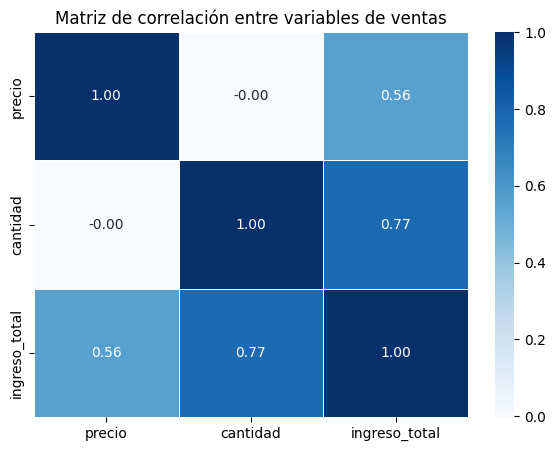

In [90]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Matriz de correlación entre variables de ventas")


plt.savefig("correlacion_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Análisis

La matriz de correlación permite evaluar el grado de relación entre las principales variables numéricas del conjunto de datos.

Se observa que la relación entre **precio** y **cantidad vendida** es prácticamente nula (-0,002), lo que indica que, dentro del conjunto analizado, el precio de un producto no presenta una influencia significativa sobre la cantidad de unidades comercializadas.

Por otra parte, el **ingreso total** muestra una correlación positiva con ambas variables analizadas. La relación más fuerte se presenta con la **cantidad vendida** (0,77), lo que sugiere que el volumen de unidades comercializadas es el principal factor asociado al incremento de los ingresos. En segundo lugar, el **precio** también mantiene una correlación positiva (0,56), aunque de menor intensidad.

En conjunto, estos resultados indican que el crecimiento de los ingresos está explicado principalmente por un mayor volumen de ventas, mientras que el precio contribuye en menor medida al resultado económico de cada operación.

### Conclusión

El análisis de correlación evidencia que el ingreso total depende tanto del precio como de la cantidad vendida, aunque la influencia de esta última resulta considerablemente mayor dentro del conjunto de datos analizado.

Asimismo, la ausencia de correlación entre precio y cantidad sugiere que ambas variables se comportan de manera independiente, permitiendo analizar su impacto sobre las ventas sin que una condicione directamente a la otra.

Estos resultados complementan el análisis exploratorio realizado previamente y sirven como base para la consolidación de la información de ventas y marketing desarrollada en la siguiente sección.

## 3.4 Consolidación de datos

En las etapas anteriores se integraron los conjuntos de datos de ventas y marketing (Etapa 2) con el objetivo de incorporar información sobre las campañas asociadas a cada operación.

A partir de esta integración, se analiza el comportamiento de las ventas según la participación o no de una campaña de marketing. Este enfoque permite evaluar si la presencia de campañas se relaciona con diferencias en el volumen de ventas y en los ingresos generados.

Los resultados obtenidos servirán además como base para la visualización interactiva desarrollada en la Etapa 4.

In [91]:
# Clasificar las ventas según tengan o no una campaña asociada

ventas_integradas["tipo_campaña"] = ventas_integradas["campana_asignada"].apply(
    lambda x: "Con campaña" if x != "Sin campaña" else "Sin campaña"
)

In [92]:
resumen_campañas = (
    ventas_integradas
    .groupby("tipo_campaña")
    .agg(
        cantidad_ventas=("id_venta","count"),
        ingresos_totales=("ingreso_total","sum"),
        ingreso_promedio=("ingreso_total","mean"),
        cantidad_productos=("cantidad","sum")
    )
)

resumen_campañas.round(2)

,cantidad_ventas,ingresos_totales,ingreso_promedio,cantidad_productos
tipo_campaña,,,,
Con campaña,2312,1131193.81,489.27,14999
Sin campaña,686,335899.71,489.65,4496


### Análisis

A partir de la integración de los datos de ventas y marketing, se comparó el desempeño de las operaciones realizadas **con campaña** y **sin campaña**.

Los resultados muestran que **2.312 ventas** estuvieron asociadas a campañas de marketing, representando la mayor parte de las operaciones registradas durante el período analizado. Estas ventas generaron ingresos por **$1.131.193,81** y un total de **14.999 unidades comercializadas**.

Por su parte, las ventas **sin campaña** registraron **686 operaciones**, con ingresos acumulados de **$335.899,71** y **4.496 unidades vendidas**.

Al comparar el ingreso promedio por venta, ambos grupos presentan valores prácticamente idénticos (**$489,27** para las ventas con campaña y **$489,65** para las ventas sin campaña). Esto indica que la diferencia en los ingresos totales se explica principalmente por una mayor cantidad de operaciones asociadas a campañas de marketing y no por un incremento en el valor promedio de cada venta.

### Conclusión

La consolidación de los datos de ventas y marketing permitió observar que la mayor parte de las operaciones del período estuvo vinculada a campañas comerciales. En consecuencia, este grupo concentró también la mayor cantidad de unidades vendidas y los ingresos acumulados más elevados.

No obstante, el ingreso promedio por venta se mantuvo prácticamente constante entre ambos grupos, lo que sugiere que el principal aporte de las campañas fue incrementar el volumen de ventas, más que modificar el valor económico de cada operación.

Este análisis integra la información proveniente de los distintos conjuntos de datos y constituye la base para las visualizaciones finales del proyecto, donde se representarán gráficamente los principales resultados obtenidos.

In [93]:
# Cambio de meses a Español

meses_es = {
    "January": "Enero",
    "February": "Febrero",
    "March": "Marzo",
    "April": "Abril",
    "May": "Mayo",
    "June": "Junio",
    "July": "Julio",
    "August": "Agosto",
    "September": "Septiembre",
    "October": "Octubre",
    "November": "Noviembre",
    "December": "Diciembre"
}

# Reemplazar los nombres de los meses

df_ventas["nombre_mes"] = df_ventas["nombre_mes"].replace(meses_es)

# Actualizar el dataframe utilizado en el análisis temporal
ventas_mensuales["nombre_mes"] = ventas_mensuales["nombre_mes"].replace(meses_es)

# Verificación

ventas_mensuales[["mes", "nombre_mes"]]

,mes,nombre_mes
0,1,Enero
1,2,Febrero
2,3,Marzo
3,4,Abril
4,5,Mayo
5,6,Junio
6,7,Julio
7,8,Agosto
8,9,Septiembre
9,10,Octubre


# Etapa 4: Visualización de Datos

En esta etapa se representan gráficamente los principales resultados obtenidos durante el análisis exploratorio y la consolidación de los datos.

Las visualizaciones permiten identificar de manera más clara la distribución de las ventas, comparar categorías y campañas de marketing, así como comunicar los principales hallazgos obtenidos a lo largo del proyecto.

## 4.1 Visualización con Seaborn

Se utilizan gráficos estadísticos para representar la distribución de las principales variables del conjunto de datos y facilitar su interpretación.

### 4.1.1 Histograma del ingreso por venta

El siguiente histograma muestra cómo se distribuyen los ingresos obtenidos por cada venta registrada.

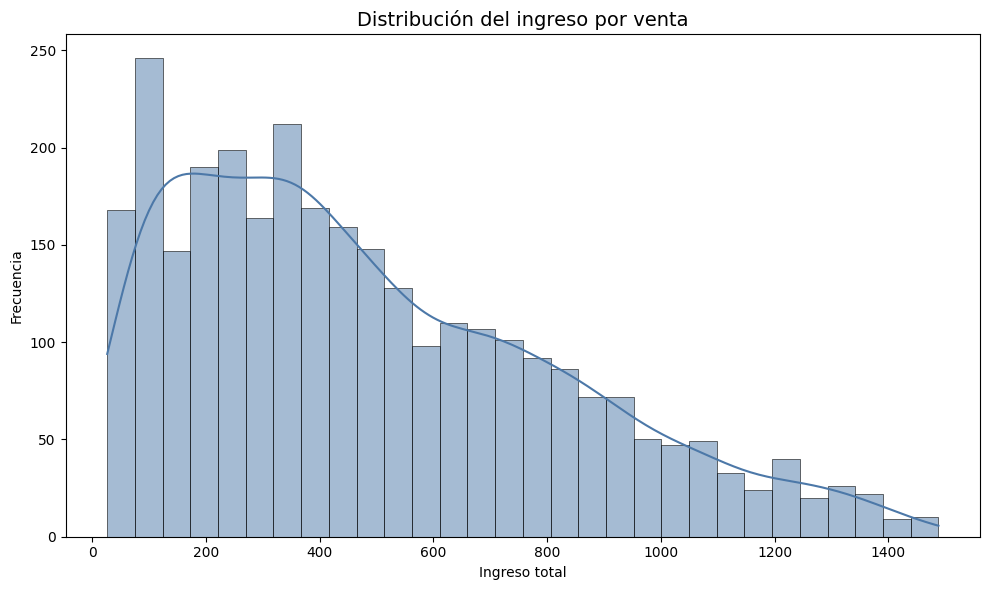

In [94]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_ventas,
    x="ingreso_total",
    bins=30,
    kde=True,
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.4
)

plt.title("Distribución del ingreso por venta", fontsize=14)
plt.xlabel("Ingreso total")
plt.ylabel("Frecuencia")

plt.tight_layout()

plt.savefig("histograma_ingresos.png",
            dpi=300,
            bbox_inches="tight")
plt.show()
plt.show()

### Análisis

El histograma muestra que la mayor parte de las ventas se concentra en los rangos de ingresos bajos e intermedios, mientras que las operaciones de mayor valor aparecen con menor frecuencia.

La distribución presenta una asimetría positiva (sesgo hacia la derecha), evidenciada por una disminución gradual en la frecuencia a medida que aumenta el ingreso total. Esto indica que existen algunas ventas con importes elevados, aunque representan una proporción reducida del total.

La forma de la distribución es consistente con las estadísticas descriptivas obtenidas anteriormente, donde la media resultó superior a la mediana y se observaron valores máximos considerablemente más altos que el resto de las ventas.

### Conclusión

La visualización confirma que la mayor parte de las operaciones corresponde a ventas de ingresos bajos e intermedios, mientras que las ventas de mayor valor son menos frecuentes. En conjunto con el análisis estadístico realizado en la Etapa 3, este gráfico permite comprender mejor el comportamiento general de los ingresos y constituye una base para interpretar las visualizaciones comparativas desarrolladas en los siguientes apartados.

### 4.1.2 Boxplot del ingreso por venta

Para complementar el histograma, se utiliza un diagrama de caja (boxplot) que permite visualizar la distribución de los ingresos por venta, identificar la mediana, el rango intercuartílico y la presencia de posibles valores atípicos.

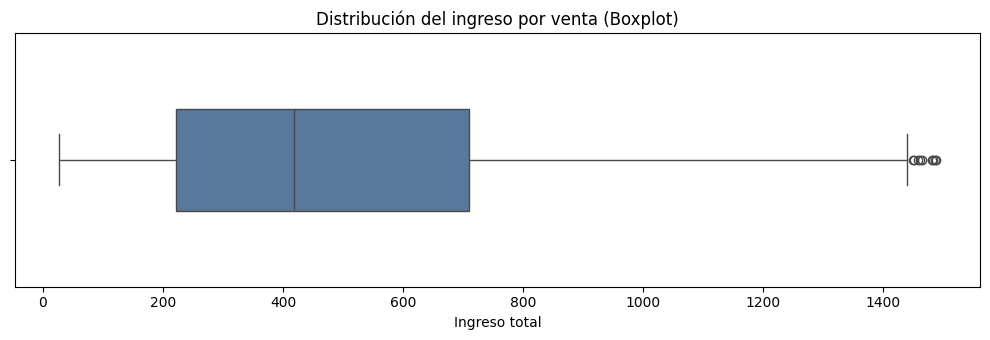

In [95]:
plt.figure(figsize=(10, 3.5))

sns.boxplot(
    x=df_ventas["ingreso_total"],
    color="#4C78A8",
    width=0.4
)

plt.title("Distribución del ingreso por venta (Boxplot)")
plt.xlabel("Ingreso total")

plt.tight_layout()

plt.savefig("boxplot_ingresos.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Análisis

El boxplot muestra que el 50 % central de los ingresos por venta se concentra entre el cuartil 1 y el cuartil 3, con una mediana claramente definida. Los bigotes indican que la mayoría de las ventas se distribuyen dentro de un rango acotado, sin gran dispersión. Sin embargo, se detectan varios valores atípicos en la parte superior, con ingresos muy superiores al resto.



### Conclusión

 La distribución es relativamente homogénea para la mayoría de las ventas, pero existen casos excepcionales de alto valor que, aunque poco frecuentes, tienen un impacto significativo en el ingreso total. Estos resultados complementan al histograma y refuerzan la necesidad de analizar por separado las ventas atípicas para entender mejor los factores que las

### 4.1.3 Ingresos por categoría de producto

A continuación se representa gráficamente el total de ingresos generados por cada categoría de producto. Esta visualización facilita la comparación del desempeño comercial entre las distintas categorías analizadas.

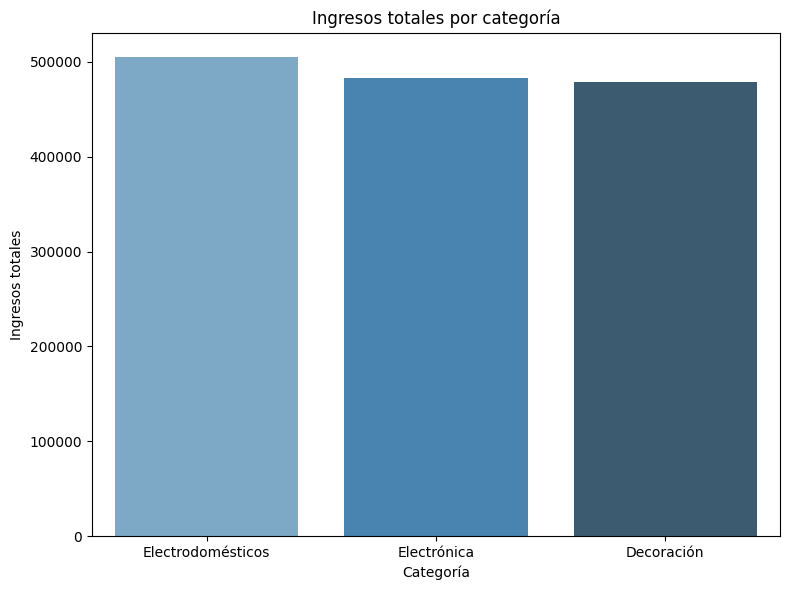

In [96]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=ingresos_categoria,
    x="categoria",
    y="ingresos_totales",
    hue="categoria",
    palette="Blues_d",
    legend=False
)

plt.title("Ingresos totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingresos totales")

plt.tight_layout()
plt.show()

### Análisis

El gráfico permite comparar los ingresos acumulados por cada categoría de producto. Se observa que **Electrodomésticos** registra el mayor volumen de ingresos durante el período analizado, seguido por **Electrónica** y **Decoración**.

No obstante, las diferencias entre las tres categorías son relativamente reducidas, lo que indica un comportamiento comercial equilibrado y una distribución homogénea de las ventas entre los distintos grupos de productos.

Esta visualización complementa el análisis realizado en la etapa anterior, permitiendo identificar rápidamente la participación de cada categoría en los ingresos totales.

### Conclusión

La categoría **Electrodomésticos** presenta el mejor desempeño en términos de ingresos acumulados, aunque las diferencias respecto de las demás categorías no son significativas. Esto sugiere que el negocio mantiene un portafolio de productos equilibrado, donde ninguna categoría concentra de manera exclusiva la mayor parte de las ventas.

### 4.1.4 Evolución mensual de las ventas

En esta visualización se representa la evolución de los ingresos obtenidos a lo largo del año. El objetivo es identificar posibles variaciones mensuales y observar el comportamiento de las ventas durante el período analizado.

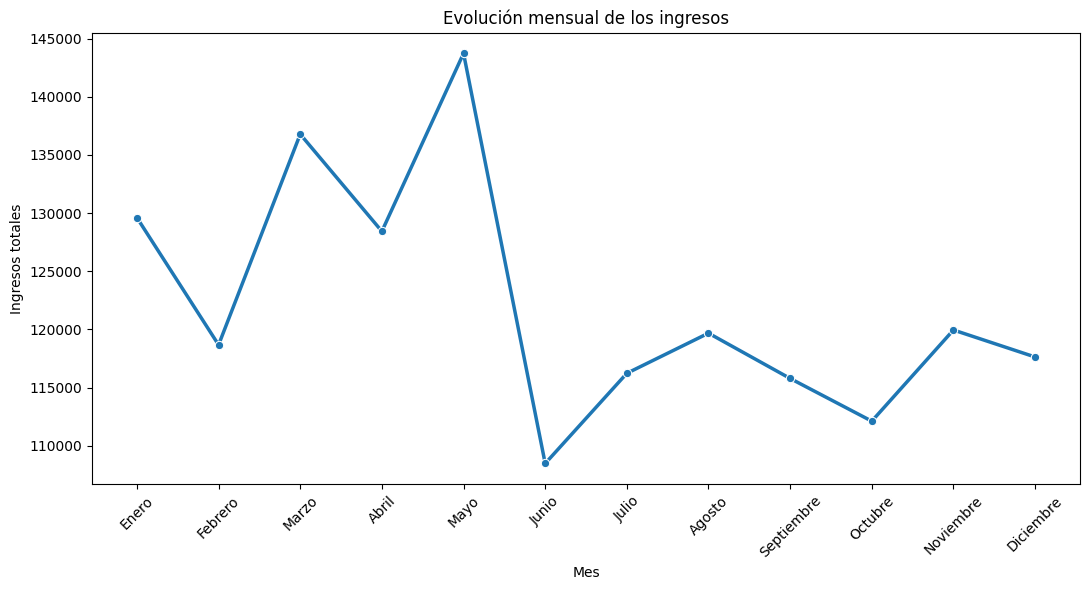

In [97]:
plt.figure(figsize=(11,6))

sns.lineplot(
    data=ventas_mensuales,
    x="nombre_mes",
    y="ingresos_totales",
    marker="o",
    linewidth=2.5
)

plt.title("Evolución mensual de los ingresos")
plt.xlabel("Mes")
plt.ylabel("Ingresos totales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("evolucion_mensual.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Análisis

La evolución mensual de los ingresos muestra un comportamiento relativamente estable a lo largo del año, sin una tendencia sostenida de crecimiento o disminución.

Se observa que **mayo** registra el mayor nivel de ingresos del período analizado, seguido por **marzo** y **enero**. En contraste, **junio** presenta el menor volumen de ingresos, aunque la diferencia respecto de los demás meses no resulta lo suficientemente amplia como para evidenciar un cambio significativo en el comportamiento de las ventas.

En términos generales, las variaciones mensuales son moderadas, lo que indica que la actividad comercial mantiene un nivel de desempeño relativamente constante durante todo el año..

### Conclusión

La evolución mensual de los ingresos evidencia dos comportamientos diferenciados durante el período analizado. Entre enero y mayo se registran los niveles de ingresos más elevados(excepto por Febrero), alcanzando el máximo anual en el mes de mayo. A partir de junio se observa un descenso en el volumen de ingresos y una estabilización en valores inferiores durante el resto del año.

Si bien no es posible determinar la causa de este cambio únicamente con la información disponible, el gráfico sugiere la existencia de un punto de inflexión a mitad del período que podría estar asociado a factores comerciales, estacionales o al comportamiento de las campañas de marketing.

## 4.2 Visualización interactiva con Plotly

Como parte de la consolidación de los datos de ventas y marketing, se genera una visualización interactiva que permite comparar el desempeño de las ventas realizadas con campaña y sin campaña.

La utilización de Plotly facilita la exploración de los datos al permitir visualizar los valores exactos de cada categoría mediante interacción con el gráfico.

In [98]:
import plotly.express as px

In [99]:
print(resumen_campañas)

              cantidad_ventas  ingresos_totales  ingreso_promedio  \
tipo_campaña                                                        
Con campaña              2312        1131193.81        489.270679   
Sin campaña               686         335899.71        489.649723   

              cantidad_productos  
tipo_campaña                      
Con campaña                14999  
Sin campaña                 4496  


In [100]:
# Convertir el índice en una columna

resumen_campañas = resumen_campañas.reset_index()

# Verificar el resultado
display(resumen_campañas)

,tipo_campaña,cantidad_ventas,ingresos_totales,ingreso_promedio,cantidad_productos
0,Con campaña,2312,1131193.81,489.270679,14999
1,Sin campaña,686,335899.71,489.649723,4496


In [101]:
!pip install -q kaleido

In [103]:
import plotly.express as px

fig = px.bar(
    resumen_campañas,
    x="tipo_campaña",
    y="ingresos_totales",
    color="tipo_campaña",
    text="ingresos_totales",

    title="Comparación de ingresos entre ventas con y sin campañas de marketing",

    labels={
        "tipo_campaña": "Tipo de campaña",
        "ingresos_totales": "Ingresos totales"
    },

    # Colores personalizados
    color_discrete_map={
        "Con campaña": "#2E86DE",
        "Sin campaña": "#AAB7B8"
    },

    # Información que aparecerá al pasar el mouse
    hover_data={
        "cantidad_ventas": True,
        "cantidad_productos": True,
        "ingreso_promedio":":,.2f"
    },

    width=850,
    height=550
)

# Formato de las etiquetas sobre las barras
fig.update_traces(
    texttemplate='$%{text:,.0f}',
    textposition='outside'
)

# Personalización general
fig.update_layout(

    showlegend=False,

    template="plotly_white",

    title={
        "text":"Comparación de ingresos entre ventas con y sin campañas de marketing",
        "x":0.5
    },

    xaxis_title="",
    yaxis_title="Ingresos totales",

    # Formato de los números del eje Y
    yaxis_tickprefix="$",
    yaxis_tickformat=",.0f",

    font=dict(
        family="Arial",
        size=14
    )
)

# Líneas de la grilla
fig.update_xaxes(showgrid=False)

fig.update_yaxes(
    gridcolor="lightgray",
    zeroline=False
)


fig.show()

### Análisis

La visualización interactiva permite comparar el desempeño de las ventas realizadas con y sin campañas de marketing a partir de la consolidación de los datos de ventas y marketing.

Se observa que las ventas asociadas a campañas concentran una mayor cantidad de operaciones y, en consecuencia, generan un mayor volumen de ingresos totales. En el período analizado, las ventas con campaña representan aproximadamente el 77 % del total de las operaciones y acumulan más de $1,13 millones en ingresos, mientras que las ventas sin campaña reúnen cerca del 23 % de las operaciones y generan alrededor de $336 mil.

Sin embargo, al comparar el ingreso promedio por venta, la diferencia entre ambos grupos resulta prácticamente inexistente. Esto indica que el mayor volumen de ingresos de las campañas no está asociado a un aumento en el valor promedio de cada venta, sino principalmente a una mayor cantidad de transacciones realizadas.

### Conclusión

La integración de los datos de ventas y marketing permitió identificar una diferencia clara entre las operaciones realizadas con y sin campañas. Las campañas concentran la mayor parte de las ventas y de los ingresos generados durante el período analizado, lo que evidencia su importancia dentro de la actividad comercial.

No obstante, el análisis también muestra que el ingreso promedio por venta se mantiene prácticamente constante entre ambos grupos. Esto sugiere que las campañas parecen favorecer un incremento en el volumen de ventas más que un aumento en el valor de cada operación individual.

Estos resultados constituyen un punto de partida para futuros análisis, en los que podría evaluarse la efectividad de cada campaña en función de indicadores adicionales, como la rentabilidad, el retorno de la inversión (ROI) o el comportamiento por categoría de producto.

# 4.3 Hallazgos e Insights del Proyecto

A partir del análisis exploratorio, la correlación entre variables y la integración de los datos de ventas y marketing, fue posible identificar distintos patrones de comportamiento en las ventas.

Los principales hallazgos obtenidos durante el desarrollo del proyecto se resumen a continuación.

### Insight 1: La cantidad vendida es el principal factor asociado a los ingresos.

El análisis de correlación mostró que la variable **cantidad** presenta una correlación positiva fuerte con el **ingreso_total** (0,77), superior a la observada entre el **precio** y el **ingreso_total** (0,56).

Esto indica que el crecimiento de los ingresos depende principalmente del volumen de productos vendidos y, en menor medida, del precio de los productos.

### Insight 2: Las ventas presentan un cambio de comportamiento durante el año.

El análisis temporal permitió identificar que los mayores ingresos se concentran entre enero y mayo, alcanzando el máximo en este último mes. A partir de junio se observa una disminución y posterior estabilización de los ingresos en niveles inferiores.

Este comportamiento sugiere la existencia de factores estacionales o comerciales que podrían analizarse con mayor profundidad utilizando información adicional.

### Insight 3: Las campañas concentran el mayor volumen de ventas.

La integración entre ventas y marketing permitió observar que las ventas asociadas a campañas representan la mayor parte de las operaciones y de los ingresos obtenidos durante el período analizado.

Sin embargo, el ingreso promedio por venta permanece prácticamente constante entre las ventas con y sin campaña, lo que indica que las campañas parecen favorecer un mayor volumen de operaciones más que un incremento en el valor individual de cada venta.

### Insight 4: Las categorías presentan un comportamiento equilibrado.

Las tres categorías analizadas (Electrónica, Electrodomésticos y Decoración) registran una cantidad de ventas e ingresos relativamente similares, sin que exista una categoría dominante durante el período analizado.

Esto evidencia una distribución homogénea de las ventas entre las diferentes líneas de productos.

## Conclusión General

El análisis realizado permitió obtener una visión integral del comportamiento de las ventas mediante la integración de los datos comerciales y de marketing. Los resultados muestran que el principal factor asociado al crecimiento de los ingresos es la cantidad de productos vendidos, mientras que el precio presenta una influencia moderada sobre el ingreso total.

Asimismo, el análisis temporal permitió identificar un cambio en la evolución de las ventas a partir del mes de junio, donde los ingresos disminuyen respecto de los primeros meses del año y se mantienen relativamente estables hasta diciembre. Este comportamiento evidencia la conveniencia de profundizar el estudio de factores estacionales o comerciales que puedan explicar esta variación.

Por otra parte, la consolidación de la información de ventas y marketing mostró que las campañas comerciales concentran la mayor cantidad de operaciones y el mayor volumen de ingresos. No obstante, el ingreso promedio por venta se mantiene prácticamente constante entre las operaciones con y sin campaña, lo que sugiere que las campañas contribuyen principalmente a incrementar el volumen de ventas y no el valor individual de cada transacción.

En función de estos resultados, futuras líneas de análisis podrían incorporar variables como costos de marketing, rentabilidad por campaña, comportamiento por categoría de producto y segmentación de clientes, con el objetivo de medir con mayor precisión la efectividad de las estrategias comerciales y optimizar la toma de decisiones basada en datos.